In [ ]:
!pip install numpyro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 12.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from sklearn.preprocessing import SplineTransformer

In [ ]:
dengue = pd.read_parquet('dengue_aggregate_2015_2025_filled.parquet')
population = pd.read_parquet('ibge_population.parquet')

In [ ]:
dengue["date"] = pd.to_datetime(dengue["date"])

dengue['total_cases_dengue'] = dengue['total_cases_dengue'].astype(int)

dengue = dengue[['date', 'uf_code', 'mun_code', 'total_cases_dengue']]
dengue = dengue.sort_values(["mun_code", "date"]).reset_index(drop=True)


In [ ]:
# total cases per municipality
top_munis = (
    dengue.groupby("mun_code")["total_cases_dengue"]
    .sum()
    .nlargest(60)
    .index
)

# keep only those municipalities
dengue = dengue[dengue["mun_code"].isin(top_munis)]

In [ ]:
# To ensure our spatial weights are positive semi definite, we must have all UFs to have >1 municipality
# so that all municipalities have at least one neighbour

uf_mun_counts = (
    dengue
    .groupby('uf_code')['mun_code']
    .nunique()
    .reset_index(name='n_mun_codes')
)
# Get the uf_codes that have multiple mun_codes
ufs_with_multiple = uf_mun_counts[uf_mun_counts['n_mun_codes'] > 1]['uf_code']

dengue = dengue[dengue["uf_code"].isin(ufs_with_multiple)]

In [ ]:
dengue_weekly = (
    dengue
    .groupby(
        ["uf_code", "mun_code", pd.Grouper(key="date", freq="W-SUN")],
        as_index=False
    )
    .sum(numeric_only=True)
)

In [ ]:
dengue_weekly

,uf_code,mun_code,date,total_cases_dengue
0,31,310620,2015-01-04,4
1,31,310620,2015-01-11,21
2,31,310620,2015-01-18,28
3,31,310620,2015-01-25,38
4,31,310620,2015-02-01,45
...,...,...,...,...
28745,52,521880,2025-12-07,58
28746,52,521880,2025-12-14,57
28747,52,521880,2025-12-21,65
28748,52,521880,2025-12-28,53


In [ ]:
# Unique municipality table
mun_lookup = (
    dengue_weekly[["mun_code", "uf_code"]]
    .drop_duplicates()
    .sort_values(["uf_code", "mun_code"])
    .reset_index(drop=True)
)

mun_lookup["mun_idx"] = np.arange(len(mun_lookup), dtype="int64")

spatial_edges = (
    mun_lookup[["mun_code", "uf_code", "mun_idx"]]
    .merge(
        mun_lookup[["mun_code", "uf_code", "mun_idx"]],
        on="uf_code",
        suffixes=("", "_nbr")
    )
)

# Remove self-neighbors
spatial_edges = spatial_edges.loc[
    spatial_edges["mun_code"] != spatial_edges["mun_code_nbr"]
].copy()

# Binary weights
spatial_edges["weight"] = 1.0

spatial_edges = spatial_edges.rename(
    columns={
        "mun_code": "mun_code",
        "mun_code_nbr": "neighbor_mun_code",
        "mun_idx": "i",
        "mun_idx_nbr": "j",
    }
)[["mun_code", "neighbor_mun_code", "i", "j", "uf_code", "weight"]]


In [ ]:
spatial_edges

,mun_code,neighbor_mun_code,i,j,uf_code,weight
1,310620,310670,0,1,31,1.0
2,310620,311830,0,2,31,1.0
3,310620,311860,0,3,31,1.0
4,310620,312230,0,4,31,1.0
5,310620,313130,0,5,31,1.0
...,...,...,...,...,...,...
709,520870,520140,48,47,52,1.0
711,520870,521880,48,49,52,1.0
712,521880,520110,49,46,52,1.0
713,521880,520140,49,47,52,1.0


In [ ]:
dengue_weekly["date"] = pd.to_datetime(dengue_weekly["date"], errors="coerce")
dengue_weekly["year"] = dengue_weekly["date"].dt.year

# use 2021 population for 2022 and 2023
dengue_weekly["pop_year"] = dengue_weekly["year"].replace({2022: 2021, 2023: 2021, 2024: 2021, 2025: 2021})

dengue_weekly = dengue_weekly.merge(
    population[["mun_code", "year", "population"]].rename(columns={"year": "pop_year"}),
    on=["mun_code", "pop_year"],
    how="left"
)
dengue_weekly = dengue_weekly.drop(columns=["year", "pop_year"])

In [ ]:
dengue_weekly = dengue_weekly[['date', 'uf_code', 'mun_code', 'population', 'total_cases_dengue']][dengue_weekly["population"].notna()]

In [ ]:
dengue_weekly

,date,uf_code,mun_code,population,total_cases_dengue
0,2015-01-04,31,310620,2502557,4
1,2015-01-11,31,310620,2502557,21
2,2015-01-18,31,310620,2502557,28
3,2015-01-25,31,310620,2502557,38
4,2015-02-01,31,310620,2502557,45
...,...,...,...,...,...
28744,2025-11-30,52,521880,247259,56
28745,2025-12-07,52,521880,247259,58
28746,2025-12-14,52,521880,247259,57
28747,2025-12-21,52,521880,247259,65


## Forecasting Dataset

In [ ]:
df = dengue_weekly.copy()

# Global weekly index
unique_dates = np.array(sorted(df["date"].unique()))
date_to_t = {d: i + 1 for i, d in enumerate(unique_dates)}
df["t"] = df["date"].map(date_to_t).astype("int64")

# Week/year for spline seasonality
iso = df["date"].dt.isocalendar()
df["epi_year"] = iso.year.astype("int64")
df["epi_week"] = iso.week.astype("int64")
df["year_idx"] = pd.Categorical(df["epi_year"]).codes.astype("int64")

# Log population offset
df["log_population"] = np.log(df["population"].clip(lower=1))

# Add municipality index
df = df.merge(
    mun_lookup[["mun_code", "mun_idx"]],
    on="mun_code",
    how="left",
    validate="m:1"
)

# # Municipality-specific lags
# for lag in [1, 2, 4, 8]:
#     df[f"lag_{lag}"] = (
#         df.groupby("mun_code")["total_cases_dengue"].shift(lag)
#     )
#     df[f"log_lag_{lag}"] = np.log1p(df[f"lag_{lag}"])


In [ ]:
num_cols = [
    "total_cases_dengue",
    "population",
    "log_population",
    "t",
    "epi_year",
    "epi_week",
    "mun_idx",
    # "lag_1", "lag_2", "lag_4", "lag_8",
    # "log_lag_1", "log_lag_2", "log_lag_4", "log_lag_8",
]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

for c in [
    "population", "log_population",
    # "lag_1", "lag_2", "lag_4", "lag_8",
    # "log_lag_1", "log_lag_2", "log_lag_4", "log_lag_8",
]:
    df[c] = df[c].astype("float64")

for c in ["t", "epi_year", "epi_week", "mun_idx"]:
    df[c] = df[c].astype("int64")

# model_df = df.dropna(
#     subset=["log_lag_1", "log_lag_2", "log_lag_4", "log_lag_8"]
# ).copy()

model_df = df.copy()

model_df["total_cases_dengue"] = (
    model_df["total_cases_dengue"].round().astype("int64")
)


In [ ]:
model_df

,date,uf_code,mun_code,population,total_cases_dengue,t,epi_year,epi_week,year_idx,log_population,mun_idx
0,2015-01-04,31,310620,2502557.0,4,1,2015,1,0,14.732824,0
1,2015-01-11,31,310620,2502557.0,21,2,2015,2,0,14.732824,0
2,2015-01-18,31,310620,2502557.0,28,3,2015,3,0,14.732824,0
3,2015-01-25,31,310620,2502557.0,38,4,2015,4,0,14.732824,0
4,2015-02-01,31,310620,2502557.0,45,5,2015,5,0,14.732824,0
...,...,...,...,...,...,...,...,...,...,...,...
28695,2025-11-30,52,521880,247259.0,56,570,2025,48,10,12.418192,49
28696,2025-12-07,52,521880,247259.0,58,571,2025,49,10,12.418192,49
28697,2025-12-14,52,521880,247259.0,57,572,2025,50,10,12.418192,49
28698,2025-12-21,52,521880,247259.0,65,573,2025,51,10,12.418192,49


In [ ]:
cutoff_date = pd.Timestamp("2024-01-01")

train_df = model_df.loc[model_df["date"] < cutoff_date].copy()
test_df  = model_df.loc[model_df["date"] >= cutoff_date].copy()

print(train_df["date"].min(), train_df["date"].max(), train_df.shape)
print(test_df["date"].min(), test_df["date"].max(), test_df.shape)

2015-01-04 00:00:00 2023-12-31 00:00:00 (23500, 11)
2024-01-07 00:00:00 2025-12-28 00:00:00 (5200, 11)


In [ ]:
spline = SplineTransformer(
    n_knots=8,
    degree=3,
    extrapolation="periodic",
    include_bias=False,
)

X_season = spline.fit_transform(train_df[["epi_week"]]).astype("float64")


In [ ]:
len(train_df)

23500

In [ ]:
X_season.shape

(23500, 6)

In [ ]:
n_mun = len(mun_lookup)
W = np.zeros((n_mun, n_mun), dtype="float64")

for row in spatial_edges.itertuples(index=False):
    W[row.i, row.j] = row.weight

# Make sure it is symmetric
W = np.maximum(W, W.T)

# No self-neighbors
np.fill_diagonal(W, 0.0)

In [ ]:
# W checks
print(W.shape)
print(np.allclose(W, W.T))          # must be True
print(np.all(np.diag(W) == 0))      # must be True

degrees = W.sum(axis=1)
print("min degree:", degrees.min())
print("n isolated:", np.sum(degrees == 0))
print("isolated mun_idx:", np.where(degrees == 0)[0])


(50, 50)
True
True
min degree: 2.0
n isolated: 0
isolated mun_idx: []


In [ ]:
n_mun = len(mun_lookup)
n_basis = X_season.shape[1]
n_year = train_df["year_idx"].nunique()
n_time = train_df["t"].nunique()


coords = {
    "obs_id": np.arange(len(train_df)),
    "municipality": mun_lookup["mun_code"].astype(str).tolist(),
    "basis": np.arange(n_basis),
    "year": np.arange(n_year),
    "time": np.arange(n_time),
}

with pm.Model(coords=coords) as model:
    # Observation-level data
    log_pop = pm.Data("log_pop", train_df["log_population"].to_numpy(), dims="obs_id")
    mun_id = pm.Data("mun_id", train_df["mun_idx"].to_numpy().astype("int64"), dims="obs_id")
    year_id = pm.Data("year_id", train_df["year_idx"].to_numpy(), dims="obs_id")
    time_id = pm.Data("time_id", train_df["t"].to_numpy().astype("int64") - 1, dims="obs_id")


    # lag1 = pm.Data("lag1", train_df["log_lag_1"].to_numpy(), dims="obs_id")
    # lag2 = pm.Data("lag2", train_df["log_lag_2"].to_numpy(), dims="obs_id")
    # lag4 = pm.Data("lag4", train_df["log_lag_4"].to_numpy(), dims="obs_id")
    # lag8 = pm.Data("lag8", train_df["log_lag_8"].to_numpy(), dims="obs_id")

    Xs = pm.Data("X_season", X_season, dims=("obs_id", "basis"))

    # Fixed effects for lag coefficient
    # beta0 = pm.Normal("beta0", 0.0, 2.0)      # the model needs a global intercept
    beta0_loc = np.log(train_df["total_cases_dengue"].sum() / train_df["population"].sum())
    beta0 = pm.Normal("beta0", mu=beta0_loc, sigma=1.0)

    # beta_1 = pm.Normal("beta_1", 0.0, 1.0)
    # beta_2 = pm.Normal("beta_2", 0.0, 1.0)
    # beta_4 = pm.Normal("beta_4", 0.0, 1.0)
    # beta_8 = pm.Normal("beta_8", 0.0, 1.0)

    # Global seasonality
    theta = pm.Normal("theta", 0.0, 1.0, dims="basis")
    season_global = pm.math.sum(Xs * theta, axis=1)

    # Year-specific seasonal deviations
    sigma_gamma = pm.HalfNormal("sigma_gamma", 0.5)
    gamma_raw = pm.Normal("gamma_raw", 0.0, 1.0, dims=("year", "basis"))
    gamma = pm.Deterministic("gamma", sigma_gamma * gamma_raw, dims=("year", "basis"))
    season_year = pm.math.sum(Xs * gamma[year_id], axis=1)

    # Spatial CAR effect
    rho_raw = pm.Beta("rho_raw", 2, 2)
    rho = pm.Deterministic("rho", 0.01 + 0.98 * rho_raw)  # force rho bw 0 and 1 for stability
    tau_u = pm.Gamma("tau_u", 2, 1)

    u = pm.CAR(
        "u",
        mu=np.zeros(n_mun),
        W=W,
        alpha=rho,
        tau=tau_u,
        dims="municipality",
    )

    # Unstructured municipality effect
    sigma_v = pm.HalfNormal("sigma_v", 1.0)
    v = pm.Normal("v", 0.0, sigma_v, dims="municipality")

    # Municipality specific AR(1) - latent epidemic effect
    rho_z = pm.Beta("rho_z", 2, 2)
    sigma_z = pm.HalfNormal("sigma_z", 1.0)

    z = pm.AR(
        "z",
        rho=rho_z,
        sigma=sigma_z,
        init_dist=pm.Normal.dist(0.0, 1.0),
        dims=("municipality", "time"),
    )

    # Linear predictor
    eta = (
        log_pop
        + beta0
        + u[mun_id]
        + v[mun_id]
        + season_global
        + season_year
        + z[mun_id, time_id]
        # + beta_1 * lag1
        # + beta_2 * lag2
        # + beta_4 * lag4
        # + beta_8 * lag8
    )

    mu = pm.Deterministic("mu", pm.math.exp(eta), dims="obs_id")

    # Negative binomial likelihood
    phi = pm.HalfNormal("phi", 2.0)

    pm.NegativeBinomial(
        "cases",
        mu=mu,
        alpha=phi,
        observed=train_df["total_cases_dengue"].to_numpy().astype("int64"),
        dims="obs_id",
    )


In [ ]:
model

In [ ]:
with model:
    idata = pm.sample(
        draws=1500,
        tune=1500,
        chains=4,
        target_accept=0.9,
        random_seed=123,
        nuts_sampler="numpyro",
        nuts_sampler_kwargs={"chain_method": "vectorized"},
    )


sample: 100%|██████████| 3000/3000 [1:04:59<00:00,  1.30s/it]
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## Model Evaluation (trace plots)

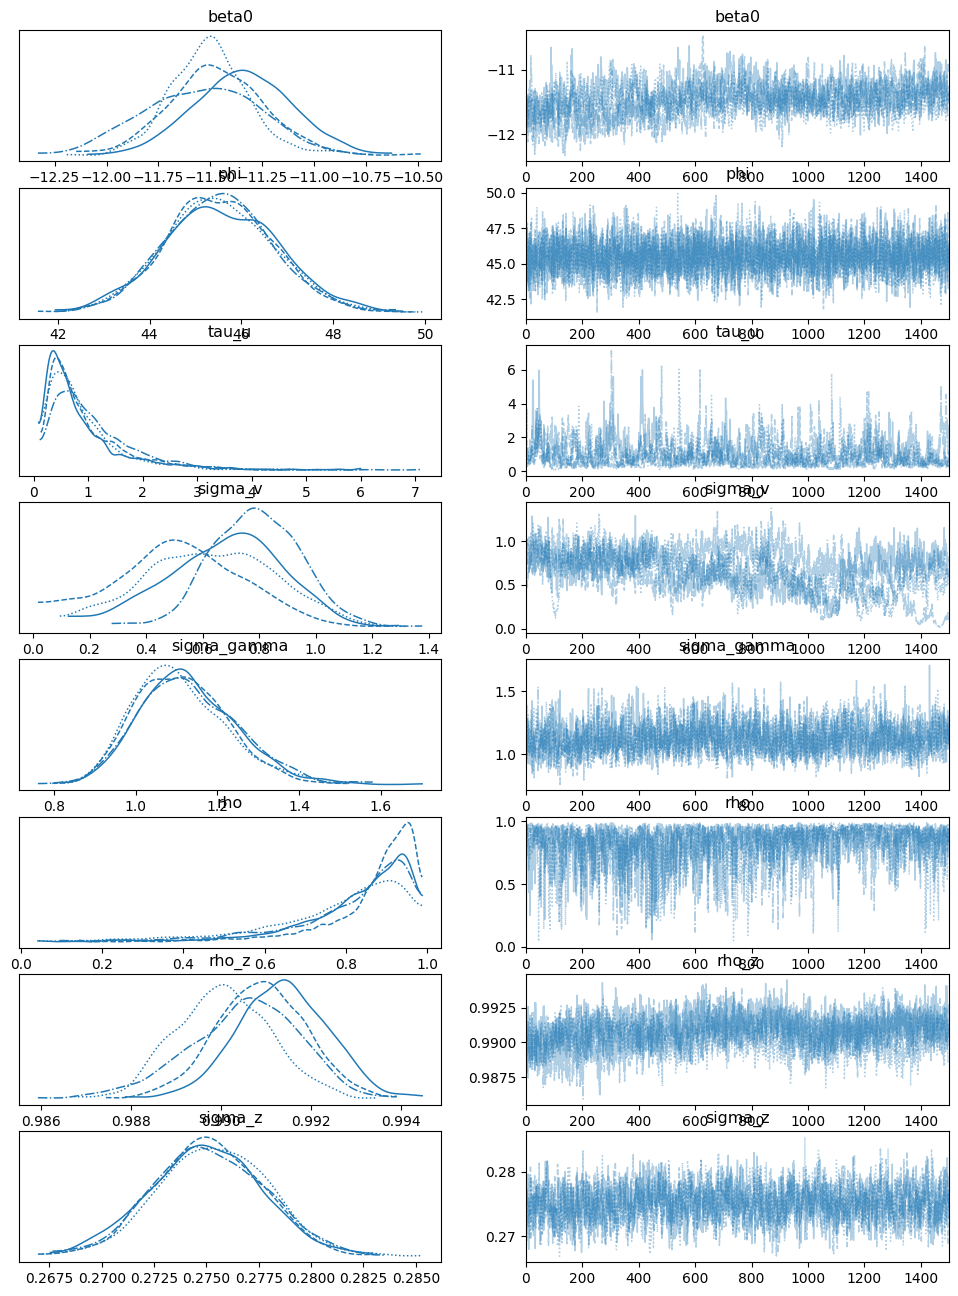

In [ ]:
# az.plot_trace(
#     idata,
#     var_names=["beta0", "beta_1", "beta_2", "beta_4", "beta_8", "phi", "tau_u", "sigma_v", "sigma_gamma", "rho"],
#     combined=False,
# )
# plt.show()


az.plot_trace(
    idata,
    var_names=["beta0", "phi", "tau_u", "sigma_v", "sigma_gamma", "rho", "rho_z", "sigma_z"],
    combined=False,
)
plt.show()


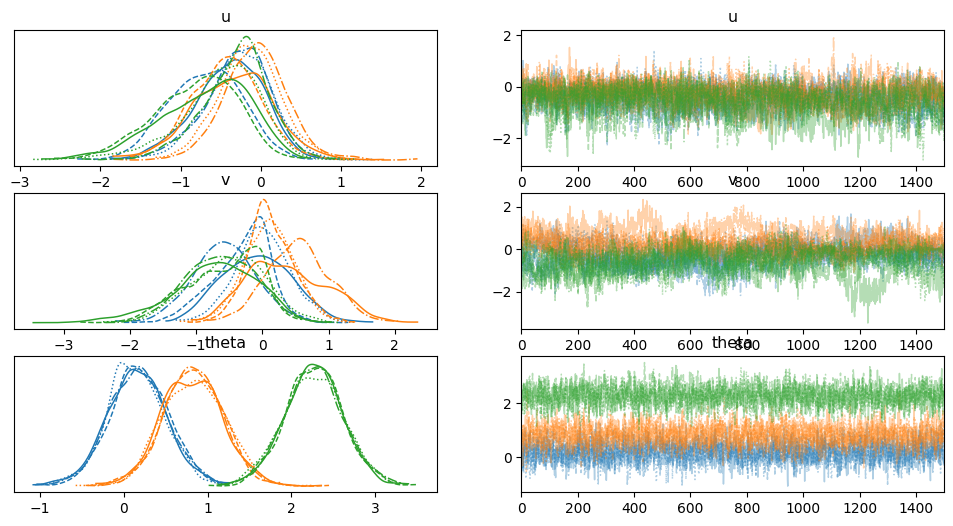

In [ ]:
az.plot_trace(
    idata,
    var_names=["u", "v", "theta"],
    coords={
        "municipality": mun_lookup["mun_code"].astype(str).tolist()[:3],
        "basis": [0, 1, 2],
    },
    combined=False,
    compact=True,
)
plt.show()


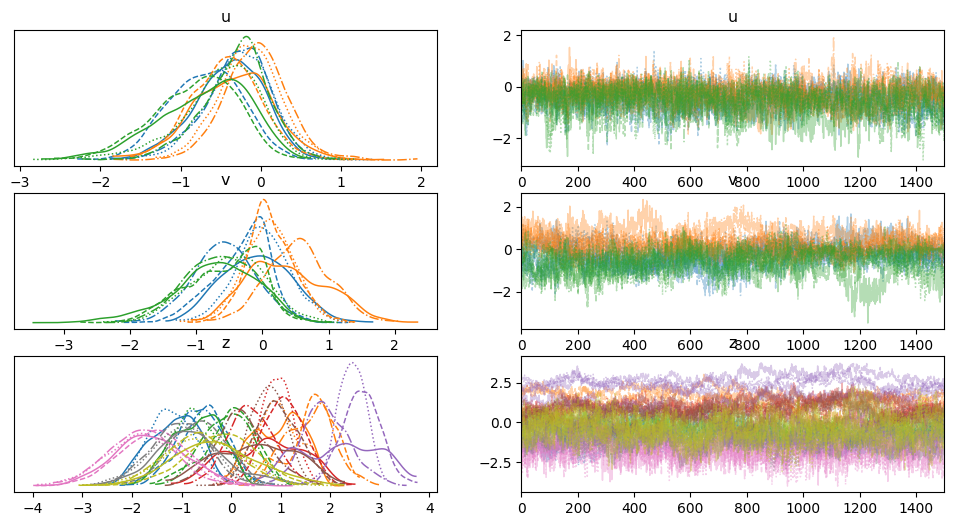

In [ ]:
az.plot_trace(
    idata,
    var_names=["u", "v", "z"],
    coords={
        "municipality": mun_lookup["mun_code"].astype(str).tolist()[:3],
        "time": [0, 20, 40],
    },
    combined=False,
    compact=True,
)
plt.show()


In [ ]:
# az.summary(
#     idata,
#     var_names=["beta0", "beta_1", "beta_2", "beta_4", "beta_8", "phi", "tau_u", "sigma_v", "sigma_gamma", "rho"]
# )

az.summary(
    idata,
    var_names=["beta0", "phi", "tau_u", "sigma_v", "sigma_gamma", "rho", "rho_z", "sigma_z"]
)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,-11.465,0.247,-11.943,-11.003,0.061,0.021,16.0,37.0,1.16
phi,45.529,1.186,43.224,47.697,0.018,0.014,4585.0,4244.0,1.00
tau_u,0.942,0.731,0.087,2.293,0.050,0.033,158.0,400.0,1.03
sigma_v,0.651,0.229,0.183,1.043,0.073,0.024,10.0,37.0,1.29
sigma_gamma,1.120,0.116,0.916,1.342,0.004,0.002,677.0,2263.0,1.01
rho,0.823,0.149,0.542,0.989,0.021,0.007,50.0,550.0,1.06
rho_z,0.991,0.001,0.988,0.993,0.000,0.000,15.0,65.0,1.17
sigma_z,0.275,0.003,0.270,0.280,0.000,0.000,1118.0,2482.0,1.00


### Spatial Terms

Structured spatial effect (u)

* mean > 0: municipality is in a higher-risk spatial cluster
* mean < 0: lower-risk spatial cluster
* rr_mean = exp(mean) gives the spatial risk ratio


Unstructured spatial effect (v)

* positive v: municipality has extra risk not explained by spatial structure
* negative v: municipality is lower than expected relative to its spatial cluster



In [ ]:
u_summary = az.summary(idata, var_names=["u"], hdi_prob=0.9)
u_summary = u_summary.reset_index().rename(columns={"index": "param"})

u_summary["mun_code"] = (
    u_summary["param"]
    .str.extract(r"u\[(.+)\]", expand=False)
    .str.replace("'", "", regex=False)
    .str.replace('"', "", regex=False)
    .astype(str)
)

u_plot_df = mun_lookup.merge(u_summary, on="mun_code", how="left")

u_plot_df["rr_mean"] = np.exp(u_plot_df["mean"])
u_plot_df["rr_low"] = np.exp(u_plot_df["hdi_5%"])
u_plot_df["rr_high"] = np.exp(u_plot_df["hdi_95%"])

u_plot_df = u_plot_df.sort_values("mean")
u_plot_df.head()

,mun_code,uf_code,mun_idx,param,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,rr_mean,rr_low,rr_high
42,420240,42,42,u[420240],-2.155,0.823,-3.505,-0.809,0.177,0.031,22.0,125.0,1.12,0.115903,0.030047,0.445303
43,420540,42,43,u[420540],-2.028,0.780,-3.260,-0.711,0.153,0.038,26.0,177.0,1.11,0.131598,0.038388,0.491153
45,420910,42,45,u[420910],-2.006,0.757,-3.279,-0.789,0.158,0.034,23.0,139.0,1.11,0.134526,0.037666,0.454299
44,420820,42,44,u[420820],-1.442,0.761,-2.638,-0.139,0.100,0.031,58.0,256.0,1.06,0.236454,0.071504,0.870228
38,410480,41,38,u[410480],-0.637,0.690,-1.754,0.504,0.141,0.053,25.0,61.0,1.11,0.528877,0.173080,1.655329


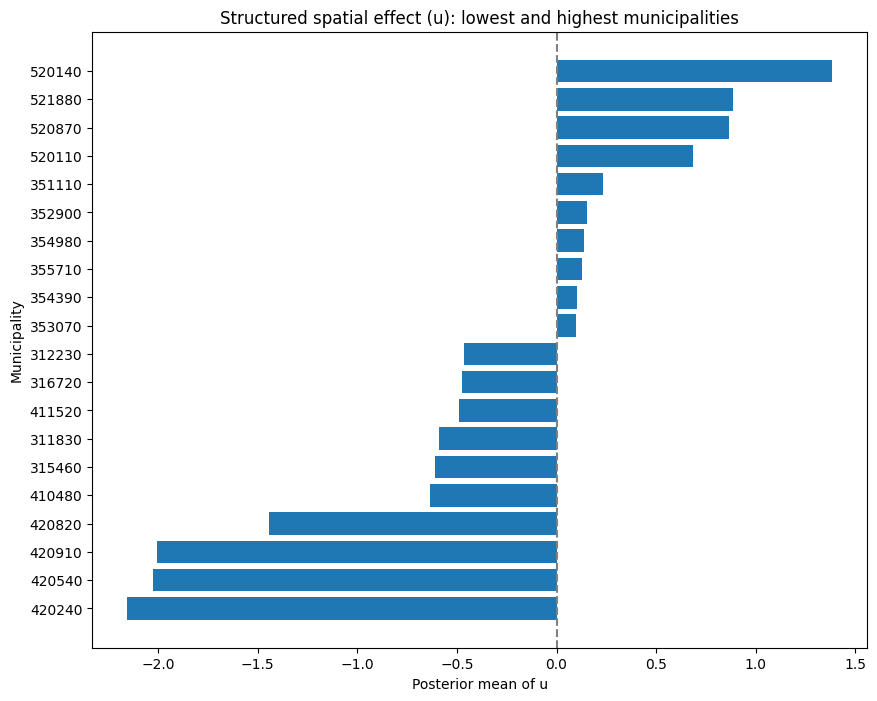

In [ ]:
u_extreme = pd.concat([
    u_plot_df.head(10),
    u_plot_df.tail(10)
])

plt.figure(figsize=(10, 8))
plt.barh(u_extreme["mun_code"], u_extreme["mean"])
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Posterior mean of u")
plt.ylabel("Municipality")
plt.title("Structured spatial effect (u): lowest and highest municipalities")
plt.show()



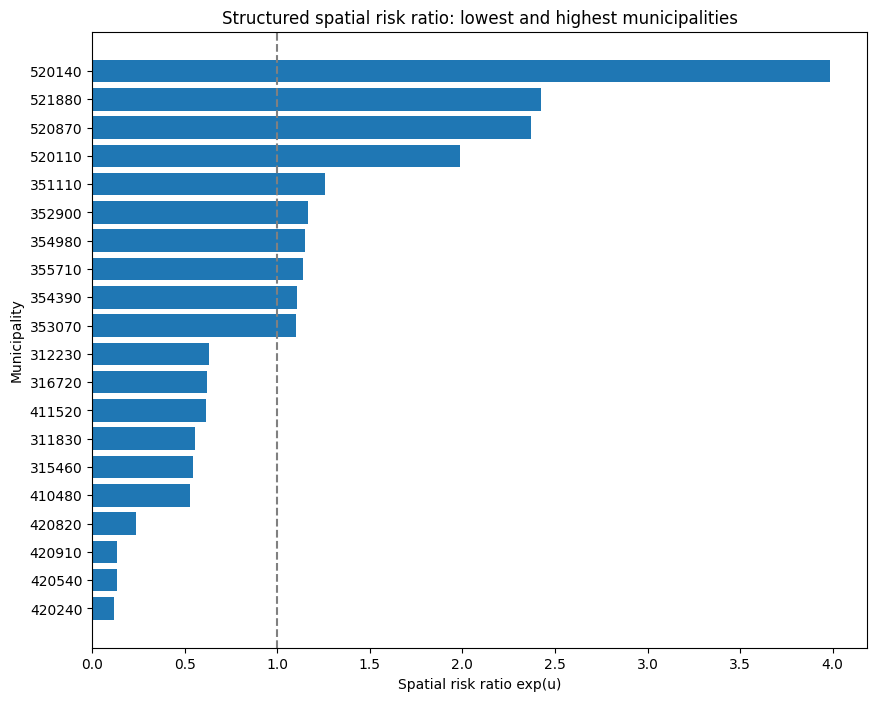

In [ ]:
u_extreme_rr = pd.concat([
    u_plot_df.sort_values("rr_mean").head(10),
    u_plot_df.sort_values("rr_mean").tail(10)
])

plt.figure(figsize=(10, 8))
plt.barh(u_extreme_rr["mun_code"], u_extreme_rr["rr_mean"])
plt.axvline(1, color="gray", linestyle="--")
plt.xlabel("Spatial risk ratio exp(u)")
plt.ylabel("Municipality")
plt.title("Structured spatial risk ratio: lowest and highest municipalities")
plt.show()


In [ ]:
v_summary = az.summary(idata, var_names=["v"], hdi_prob=0.9)
v_summary = v_summary.reset_index().rename(columns={"index": "param"})

v_summary["mun_code"] = (
    v_summary["param"]
    .str.extract(r"v\[(.+)\]", expand=False)
    .str.replace("'", "", regex=False)
    .str.replace('"', "", regex=False)
    .astype(str)
)

v_plot_df = mun_lookup.merge(v_summary, on="mun_code", how="left")

v_plot_df["rr_mean"] = np.exp(v_plot_df["mean"])
v_plot_df["rr_low"] = np.exp(v_plot_df["hdi_5%"])
v_plot_df["rr_high"] = np.exp(v_plot_df["hdi_95%"])

v_plot_df = v_plot_df.sort_values("mean")
v_plot_df.head()


,mun_code,uf_code,mun_idx,param,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,rr_mean,rr_low,rr_high
33,355030,35,33,v[355030],-0.935,0.624,-1.940,0.034,0.240,0.076,7.0,25.0,1.54,0.392586,0.143704,1.034585
7,315460,31,7,v[315460],-0.770,0.647,-1.794,0.215,0.156,0.092,19.0,30.0,1.15,0.463013,0.166294,1.239862
2,311830,31,2,v[311830],-0.616,0.583,-1.522,0.314,0.095,0.035,37.0,150.0,1.07,0.540101,0.218275,1.368890
42,420240,42,42,v[420240],-0.584,0.681,-1.703,0.445,0.088,0.023,64.0,431.0,1.04,0.557663,0.182136,1.560490
43,420540,42,43,v[420540],-0.455,0.678,-1.572,0.600,0.115,0.045,38.0,128.0,1.07,0.634448,0.207630,1.822119


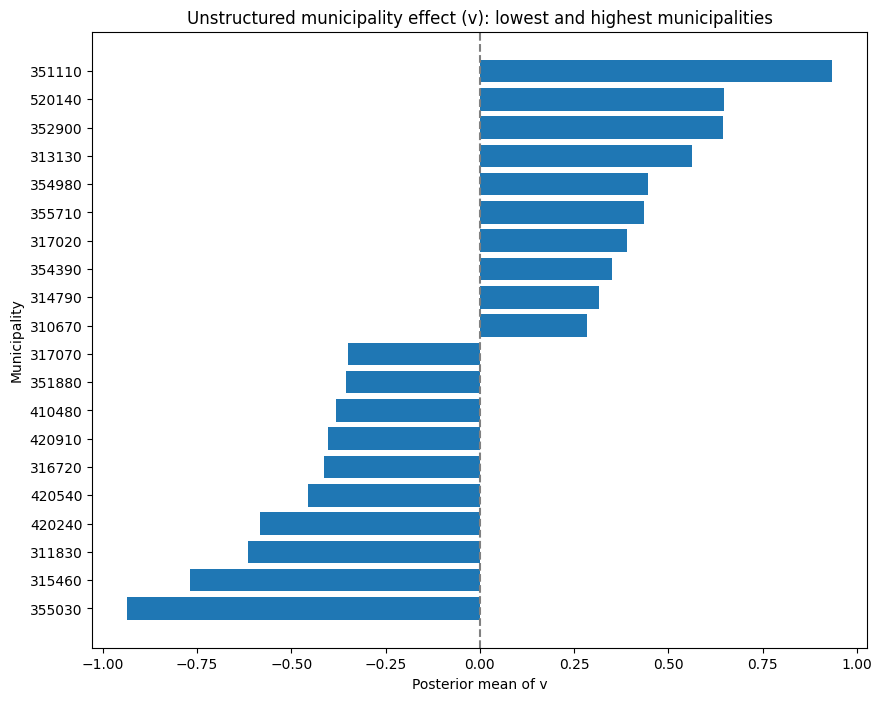

In [ ]:
v_extreme = pd.concat([
    v_plot_df.head(10),
    v_plot_df.tail(10)
])

plt.figure(figsize=(10, 8))
plt.barh(v_extreme["mun_code"], v_extreme["mean"])
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Posterior mean of v")
plt.ylabel("Municipality")
plt.title("Unstructured municipality effect (v): lowest and highest municipalities")
plt.show()


### Temporal Terms

Global seasonal curve (theta)

* above 0 on log scale means elevated seasonal risk
* above 1 on multiplier scale means higher-than-baseline seasonal intensity


Year-specific seasonal curves




In [ ]:
post = idata.posterior.stack(sample=("chain", "draw"))
theta_draws = post["theta"].transpose("sample", "basis").values

week_grid = pd.DataFrame({"epi_week": np.arange(1, 53)})
X_week = spline.transform(week_grid[["epi_week"]]).astype("float64")

season_global_draws = X_week @ theta_draws.T

season_global_df = pd.DataFrame({
    "epi_week": week_grid["epi_week"],
    "mean": season_global_draws.mean(axis=1),
    "low": np.quantile(season_global_draws, 0.05, axis=1),
    "high": np.quantile(season_global_draws, 0.95, axis=1),
})

season_global_df["mult_mean"] = np.exp(season_global_df["mean"])
season_global_df["mult_low"] = np.exp(season_global_df["low"])
season_global_df["mult_high"] = np.exp(season_global_df["high"])


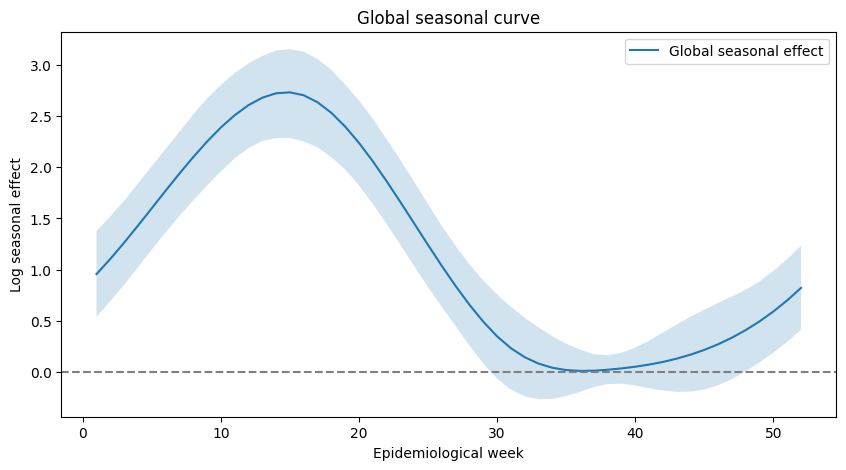

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(season_global_df["epi_week"], season_global_df["mean"], label="Global seasonal effect")
plt.fill_between(
    season_global_df["epi_week"],
    season_global_df["low"],
    season_global_df["high"],
    alpha=0.2
)
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Epidemiological week")
plt.ylabel("Log seasonal effect")
plt.title("Global seasonal curve")
plt.legend()
plt.show()


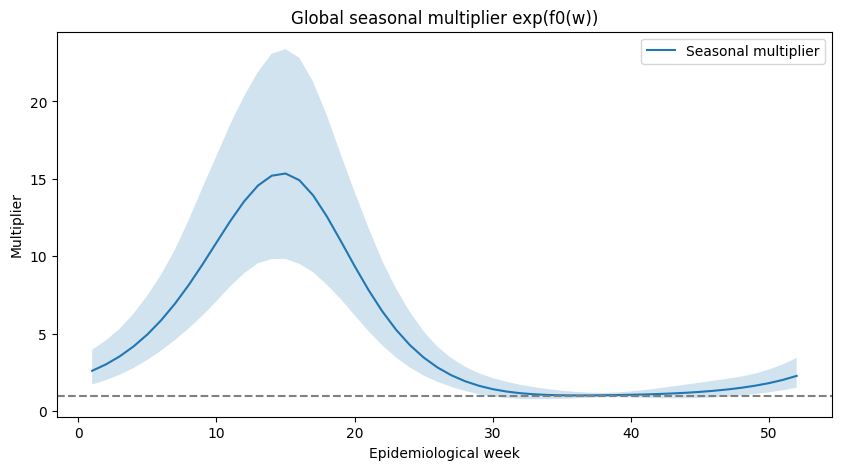

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(season_global_df["epi_week"], season_global_df["mult_mean"], label="Seasonal multiplier")
plt.fill_between(
    season_global_df["epi_week"],
    season_global_df["mult_low"],
    season_global_df["mult_high"],
    alpha=0.2
)
plt.axhline(1, color="gray", linestyle="--")
plt.xlabel("Epidemiological week")
plt.ylabel("Multiplier")
plt.title("Global seasonal multiplier exp(f0(w))")
plt.legend()
plt.show()


In [ ]:
gamma_draws = post["gamma"].transpose("sample", "year", "basis").values
year_levels = np.sort(train_df["epi_year"].unique())

year_curve_parts = []

for y_idx, year in enumerate(year_levels):
    total_draws = season_global_draws + (X_week @ gamma_draws[:, y_idx, :].T)

    tmp = pd.DataFrame({
        "epi_week": week_grid["epi_week"],
        "epi_year": year,
        "mean": total_draws.mean(axis=1),
        "low": np.quantile(total_draws, 0.05, axis=1),
        "high": np.quantile(total_draws, 0.95, axis=1),
    })
    year_curve_parts.append(tmp)

year_curve_df = pd.concat(year_curve_parts, ignore_index=True)


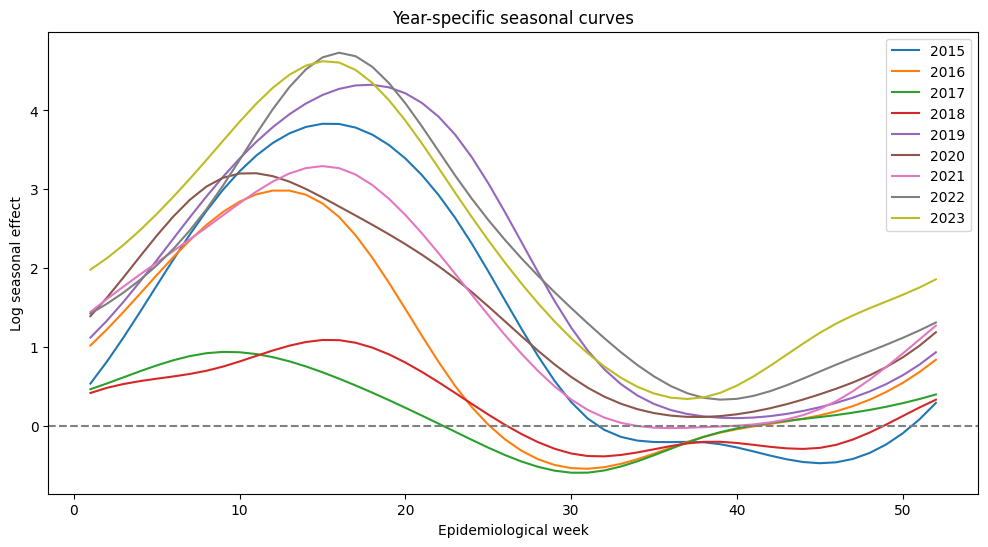

In [ ]:
plt.figure(figsize=(12, 6))

for year in year_levels:
    tmp = year_curve_df[year_curve_df["epi_year"] == year]
    plt.plot(tmp["epi_week"], tmp["mean"], label=str(year))

plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Epidemiological week")
plt.ylabel("Log seasonal effect")
plt.title("Year-specific seasonal curves")
plt.legend()
plt.show()


## Posterior Predictive Checking

In [ ]:
with model:
    idata_ppc = pm.sample_posterior_predictive(
        idata,
        var_names=["cases"],
        random_seed=123,
        extend_inferencedata=False,
    )

Output()

In [ ]:
y_rep = (
    idata_ppc.posterior_predictive["cases"]
    .stack(sample=("chain", "draw"))
    .transpose("sample", "obs_id")
    .values
)

y_obs = train_df["total_cases_dengue"].to_numpy()


In [ ]:
def acf_lag(x, lag):
    x = np.asarray(x, dtype=float)
    if lag >= len(x):
        return np.nan
    x1 = x[:-lag]
    x2 = x[lag:]
    if np.std(x1) == 0 or np.std(x2) == 0:
        return np.nan
    return np.corrcoef(x1, x2)[0, 1]

lags = np.arange(1, 21)

obs_weekly = (
    train_df.groupby("date")["total_cases_dengue"]
    .sum()
    .sort_index()
    .to_numpy()
)

acf_obs_weekly = np.array([acf_lag(obs_weekly, lag) for lag in lags])


In [ ]:
acf_rep_weekly = []

for s in range(y_rep.shape[0]):
    tmp = train_df[["date"]].copy()
    tmp["y_rep"] = y_rep[s]

    rep_weekly = (
        tmp.groupby("date")["y_rep"]
        .sum()
        .sort_index()
        .to_numpy()
    )

    acf_rep_weekly.append([acf_lag(rep_weekly, lag) for lag in lags])

acf_rep_weekly = np.asarray(acf_rep_weekly)


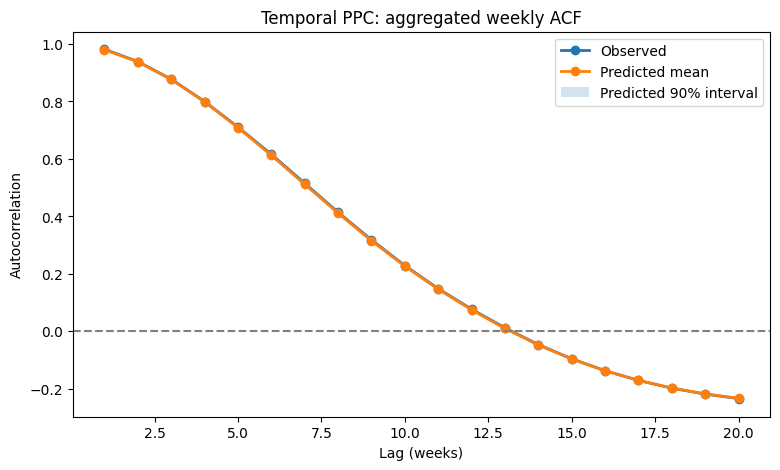

In [ ]:
ppc_weekly_mean = np.nanmean(acf_rep_weekly, axis=0)
ppc_weekly_low = np.nanquantile(acf_rep_weekly, 0.05, axis=0)
ppc_weekly_high = np.nanquantile(acf_rep_weekly, 0.95, axis=0)

plt.figure(figsize=(9, 5))
plt.plot(lags, acf_obs_weekly, marker="o", label="Observed", linewidth=2)
plt.plot(lags, ppc_weekly_mean, marker="o", label="Predicted mean", linewidth=2)
plt.fill_between(
    lags,
    ppc_weekly_low,
    ppc_weekly_high,
    alpha=0.2,
    label="Predicted 90% interval"
)
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Lag (weeks)")
plt.ylabel("Autocorrelation")
plt.title("Temporal PPC: aggregated weekly ACF")
plt.legend()
plt.show()

In [ ]:
mun_codes = train_df["mun_code"].astype(str).unique()

acf_obs_mun = []

for mun in mun_codes:
    series = (
        train_df.loc[train_df["mun_code"].astype(str) == mun]
        .sort_values("date")["total_cases_dengue"]
        .to_numpy()
    )
    acf_obs_mun.append([acf_lag(series, lag) for lag in lags])

acf_obs_mun = np.asarray(acf_obs_mun)

acf_obs_mun_mean = np.nanmean(acf_obs_mun, axis=0)
acf_obs_mun_low = np.nanquantile(acf_obs_mun, 0.05, axis=0)
acf_obs_mun_high = np.nanquantile(acf_obs_mun, 0.95, axis=0)


base_panel = train_df[["mun_code", "date"]].copy().reset_index(drop=True)

acf_rep_mun_mean = []

for s in range(y_rep.shape[0]):
    tmp = base_panel.copy()
    tmp["y_rep"] = y_rep[s]

    mun_acfs = []
    for mun in mun_codes:
        series = (
            tmp.loc[tmp["mun_code"].astype(str) == mun]
            .sort_values("date")["y_rep"]
            .to_numpy()
        )
        mun_acfs.append([acf_lag(series, lag) for lag in lags])

    mun_acfs = np.asarray(mun_acfs)
    acf_rep_mun_mean.append(np.nanmean(mun_acfs, axis=0))

acf_rep_mun_mean = np.asarray(acf_rep_mun_mean)



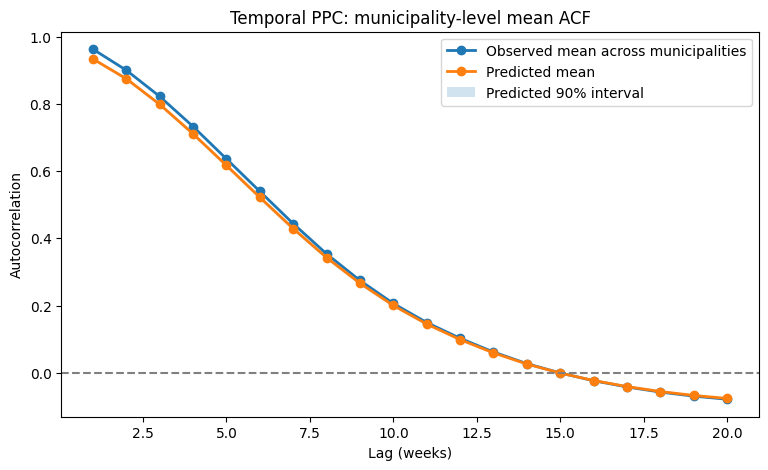

In [ ]:
ppc_mun_mean = np.nanmean(acf_rep_mun_mean, axis=0)
ppc_mun_low = np.nanquantile(acf_rep_mun_mean, 0.05, axis=0)
ppc_mun_high = np.nanquantile(acf_rep_mun_mean, 0.95, axis=0)

plt.figure(figsize=(9, 5))
plt.plot(lags, acf_obs_mun_mean, marker="o", label="Observed mean across municipalities", linewidth=2)
plt.plot(lags, ppc_mun_mean, marker="o", label="Predicted mean", linewidth=2)
plt.fill_between(
    lags,
    ppc_mun_low,
    ppc_mun_high,
    alpha=0.2,
    label="Predicted 90% interval"
)
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Lag (weeks)")
plt.ylabel("Autocorrelation")
plt.title("Temporal PPC: municipality-level mean ACF")
plt.legend()
plt.show()


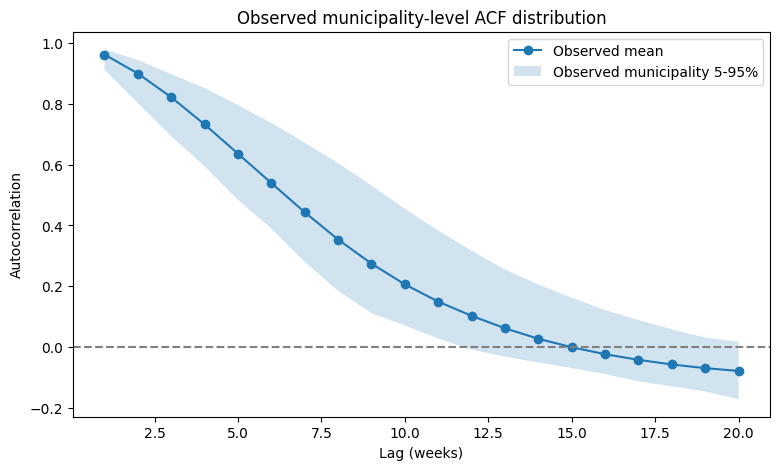

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(lags, acf_obs_mun_mean, marker="o", label="Observed mean")
plt.fill_between(
    lags,
    acf_obs_mun_low,
    acf_obs_mun_high,
    alpha=0.2,
    label="Observed municipality 5-95%"
)
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Lag (weeks)")
plt.ylabel("Autocorrelation")
plt.title("Observed municipality-level ACF distribution")
plt.legend()
plt.show()

In [ ]:
obs_season = (
    train_df.groupby("epi_week")
    .apply(lambda g: g["total_cases_dengue"].sum() / g["population"].sum())
    .sort_index()
)

rep_season = []
for s in range(y_rep.shape[0]):
    tmp = train_df[["epi_week", "population"]].copy()
    tmp["y_rep"] = y_rep[s]
    curve = (
        tmp.groupby("epi_week")
        .apply(lambda g: g["y_rep"].sum() / g["population"].sum())
        .sort_index()
        .to_numpy()
    )
    rep_season.append(curve)

rep_season = np.asarray(rep_season)


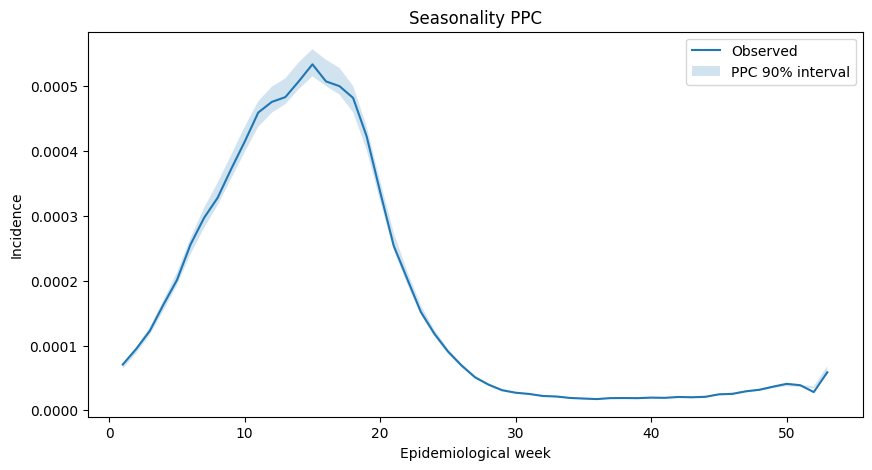

In [ ]:
weeks = obs_season.index.to_numpy()

plt.figure(figsize=(10, 5))
plt.plot(weeks, obs_season.to_numpy(), label="Observed")
plt.fill_between(
    weeks,
    np.quantile(rep_season, 0.05, axis=0),
    np.quantile(rep_season, 0.95, axis=0),
    alpha=0.2,
    label="PPC 90% interval"
)
plt.xlabel("Epidemiological week")
plt.ylabel("Incidence")
plt.title("Seasonality PPC")
plt.legend()
plt.show()


In [ ]:
edge_pairs = spatial_edges[["i", "j"]].drop_duplicates().to_numpy()

def spatial_smoothness(y_vec, dates, edge_pairs):
    df = pd.DataFrame({"date": dates, "y": y_vec})
    out = []
    for d, idx in df.groupby("date").groups.items():
        vals = y_vec[np.array(list(idx))]
        diffs = np.abs(vals[edge_pairs[:, 0]] - vals[edge_pairs[:, 1]])
        out.append(diffs.mean())
    return np.array(out)

dates = train_df["date"].to_numpy()
obs_spatial = spatial_smoothness(y_obs, dates, edge_pairs)

rep_spatial = np.vstack([
    spatial_smoothness(y_rep[s], dates, edge_pairs)
    for s in range(y_rep.shape[0])
])


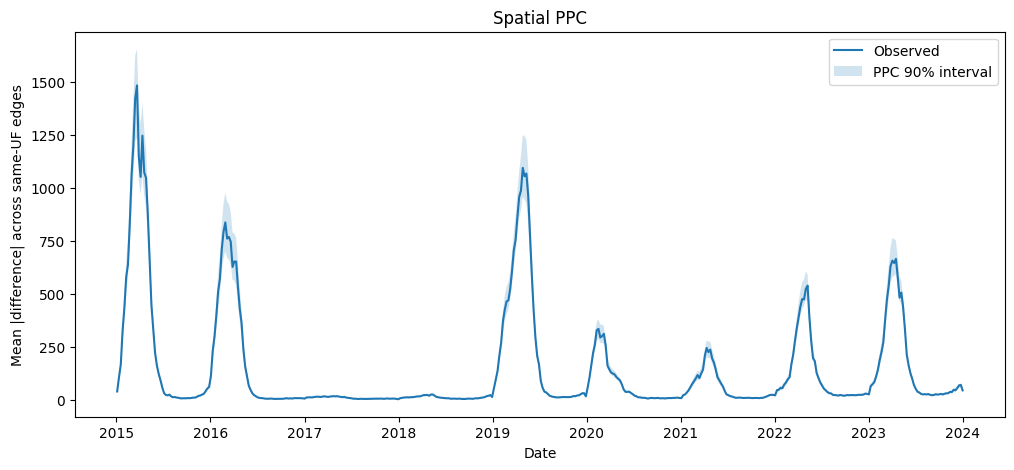

In [ ]:
week_dates = np.sort(train_df["date"].unique())

plt.figure(figsize=(12, 5))
plt.plot(week_dates, obs_spatial, label="Observed")
plt.fill_between(
    week_dates,
    np.quantile(rep_spatial, 0.05, axis=0),
    np.quantile(rep_spatial, 0.95, axis=0),
    alpha=0.2,
    label="PPC 90% interval"
)
plt.xlabel("Date")
plt.ylabel("Mean |difference| across same-UF edges")
plt.title("Spatial PPC")
plt.legend()
plt.show()


## Forecast Evaluation

In [ ]:
rng = np.random.default_rng(123)

# Forecast horizon
forecast_dates = sorted(test_df["date"].unique())[:20]

# Flatten posterior draws
post = idata.posterior.stack(sample=("chain", "draw"))

beta0_draws = post["beta0"].values
# beta1_draws = post["beta_1"].values
# beta2_draws = post["beta_2"].values
# beta4_draws = post["beta_4"].values
# beta8_draws = post["beta_8"].values

theta_draws = post["theta"].transpose("sample", "basis").values
gamma_draws = post["gamma"].transpose("sample", "year", "basis").values
sigma_gamma_draws = post["sigma_gamma"].values

u_draws = post["u"].transpose("sample", "municipality").values
v_draws = post["v"].transpose("sample", "municipality").values
phi_draws = post["phi"].values

rho_z_draws = post["rho_z"].values
sigma_z_draws = post["sigma_z"].values
z_draws = post["z"].transpose("sample", "municipality", "time").values

n_total_samples = post.sizes["sample"]
n_paths = min(1000, n_total_samples)
sample_idx = rng.choice(np.arange(n_total_samples), size=n_paths, replace=False)

# Training-year lookup
train_year_levels = np.sort(train_df["epi_year"].unique())
train_year_to_idx = {y: i for i, y in enumerate(train_year_levels)}

# Per-path recursive history
# history_list = [train_df.copy() for _ in range(n_paths)]    # Needed for fixed lag term
last_z_list = [
    z_draws[s, :, train_df["t"].nunique() - 1].copy()
    for s in sample_idx
]


# Cache unseen-year random effects so each path uses one consistent effect per new year
year_effect_cache = [dict() for _ in range(n_paths)]

pred_parts = []

def sample_nb(mu, alpha, rng):
    # PyMC NegativeBinomial(mu=mu, alpha=alpha)
    lam = rng.gamma(shape=alpha, scale=mu / alpha)
    return rng.poisson(lam)

for d in forecast_dates:
    path_preds = []
    current_template = None

    for j, s in enumerate(sample_idx):
        current = test_df.loc[test_df["date"] == d].copy()

        # temp = (
        #     pd.concat([history_list[j], current], ignore_index=True)
        #     .sort_values(["mun_code", "date"])
        #     .reset_index(drop=True)
        # )

        # for lag in [1, 2, 4, 8]:
        #     temp[f"lag_{lag}"] = (
        #         temp.groupby("mun_code")["total_cases_dengue"].shift(lag)
        #     )
        #     temp[f"log_lag_{lag}"] = np.log1p(temp[f"lag_{lag}"])

        # current = temp.loc[temp["date"] == d].copy()

        # Seasonal basis for the current week rows
        X_current = spline.transform(current[["epi_week"]]).astype("float64")

        # Global seasonal component
        season_global = X_current @ theta_draws[s]

        # Year-specific seasonal component
        current_year = int(current["epi_year"].iloc[0])

        if current_year in train_year_to_idx:
            yidx = train_year_to_idx[current_year]
            season_year = X_current @ gamma_draws[s, yidx, :]
        else:
            if current_year not in year_effect_cache[j]:
                year_effect_cache[j][current_year] = rng.normal(
                    loc=0.0,
                    scale=sigma_gamma_draws[s],
                    size=X_current.shape[1],
                )
            gamma_new = year_effect_cache[j][current_year]
            season_year = X_current @ gamma_new

        # Spatial effects
        mun_ids = current["mun_idx"].to_numpy().astype("int64")
        spatial_term = u_draws[s, mun_ids] + v_draws[s, mun_ids]

        # Latent state propagation
        z_prev = last_z_list[j][mun_ids]
        z_current = rho_z_draws[s] * z_prev + rng.normal(
            loc=0.0,
            scale=sigma_z_draws[s],
            size=len(mun_ids),
        )


        # Linear predictor
        eta = (
            current["log_population"].to_numpy()
            + beta0_draws[s]
            + spatial_term
            + season_global
            + season_year
            + z_current
            # + beta1_draws[s] * current["log_lag_1"].to_numpy()
            # + beta2_draws[s] * current["log_lag_2"].to_numpy()
            # + beta4_draws[s] * current["log_lag_4"].to_numpy()
            # + beta8_draws[s] * current["log_lag_8"].to_numpy()
        )

        mu = np.exp(eta)
        y_path = sample_nb(mu=mu, alpha=phi_draws[s], rng=rng)   # Use for stochastic recursion
        #y_path = mu                                               # Use for deterministic recursion

        path_preds.append(y_path)

        # history_append = current.copy()
        # history_append["total_cases_dengue"] = y_path
        # history_list[j] = pd.concat(
        #     [history_list[j], history_append[history_list[j].columns]],
        #     ignore_index=True
        # )

        last_z_list[j][mun_ids] = z_current

        if current_template is None:
            current_template = current.copy()

    path_preds = np.column_stack(path_preds)

    current_template["y_pred"] = path_preds.mean(axis=1)
    current_template["y_lower"] = np.quantile(path_preds, 0.05, axis=1)
    current_template["y_upper"] = np.quantile(path_preds, 0.95, axis=1)
    current_template["y_true"] = test_df.loc[
        test_df["date"] == d, "total_cases_dengue"
    ].to_numpy()

    pred_parts.append(current_template)

pred_df = pd.concat(pred_parts, ignore_index=True)


In [ ]:
pred_df["abs_error"] = (pred_df["y_pred"] - pred_df["y_true"]).abs()
pred_df["sq_error"] = (pred_df["y_pred"] - pred_df["y_true"]) ** 2
pred_df["covered"] = (
    (pred_df["y_true"] >= pred_df["y_lower"]) &
    (pred_df["y_true"] <= pred_df["y_upper"])
)

print("MAE:", pred_df["abs_error"].mean())
print("RMSE:", np.sqrt(pred_df["sq_error"].mean()))
print("90% coverage:", pred_df["covered"].mean())

MAE: 1862.3141260000002
RMSE: 5411.802688690855
90% coverage: 0.205


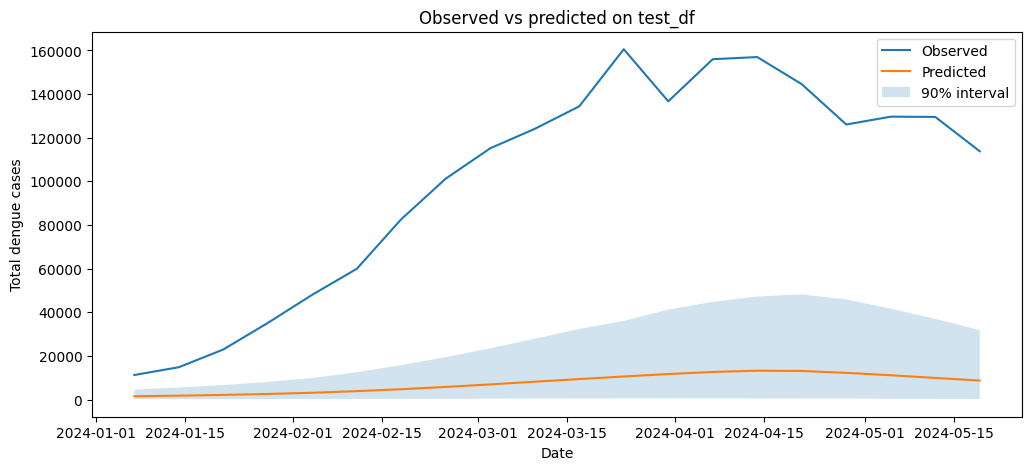

In [ ]:
plot_df = (
    pred_df.groupby("date", as_index=False)
    .agg(
        y_true=("y_true", "sum"),
        y_pred=("y_pred", "sum"),
        y_lower=("y_lower", "sum"),
        y_upper=("y_upper", "sum"),
    )
    .sort_values("date")
)

plt.figure(figsize=(12, 5))
plt.plot(plot_df["date"], plot_df["y_true"], label="Observed")
plt.plot(plot_df["date"], plot_df["y_pred"], label="Predicted")
plt.fill_between(
    plot_df["date"],
    plot_df["y_lower"],
    plot_df["y_upper"],
    alpha=0.2,
    label="90% interval"
)
plt.legend()
plt.title("Observed vs predicted on test_df")
plt.xlabel("Date")
plt.ylabel("Total dengue cases")
plt.show()

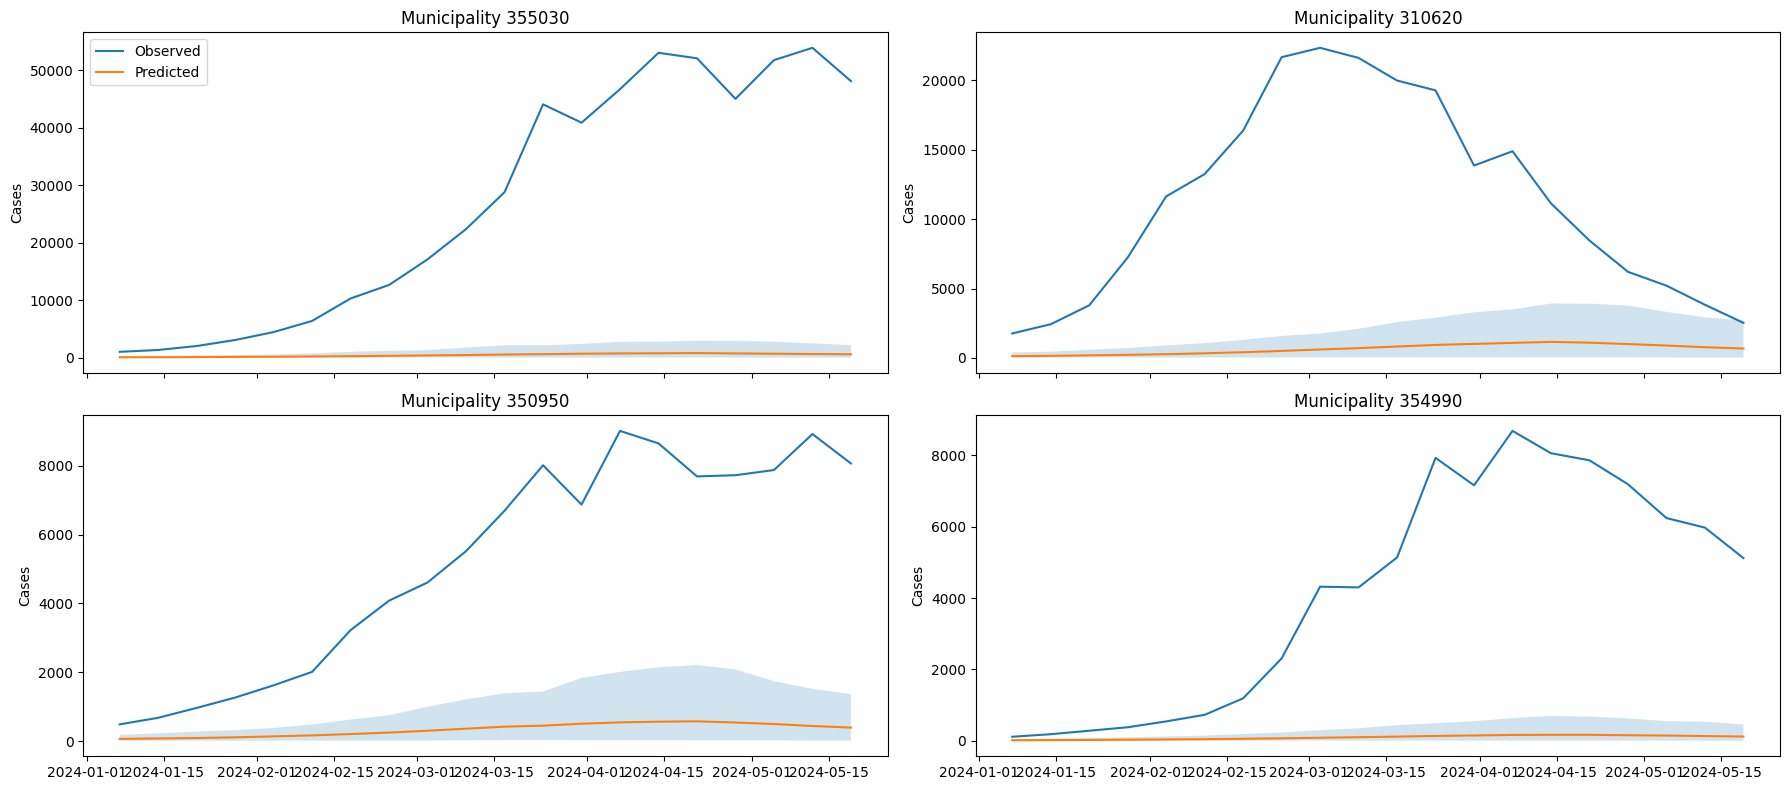

In [ ]:
# Top 6 municipalities by total observed cases in the test set
top6 = (
    pred_df.groupby("mun_code")["y_true"]
    .sum()
    .sort_values(ascending=False)
    .head(4)
    .index
)

fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for ax, m in zip(axes, top6):

    d = pred_df.loc[pred_df["mun_code"] == m].sort_values("date")

    ax.plot(d["date"], d["y_true"], label="Observed")
    ax.plot(d["date"], d["y_pred"], label="Predicted")

    ax.fill_between(
        d["date"],
        d["y_lower"],
        d["y_upper"],
        alpha=0.2
    )

    ax.set_title(f"Municipality {m}")
    ax.set_ylabel("Cases")

axes[0].legend()

plt.tight_layout()
plt.show()

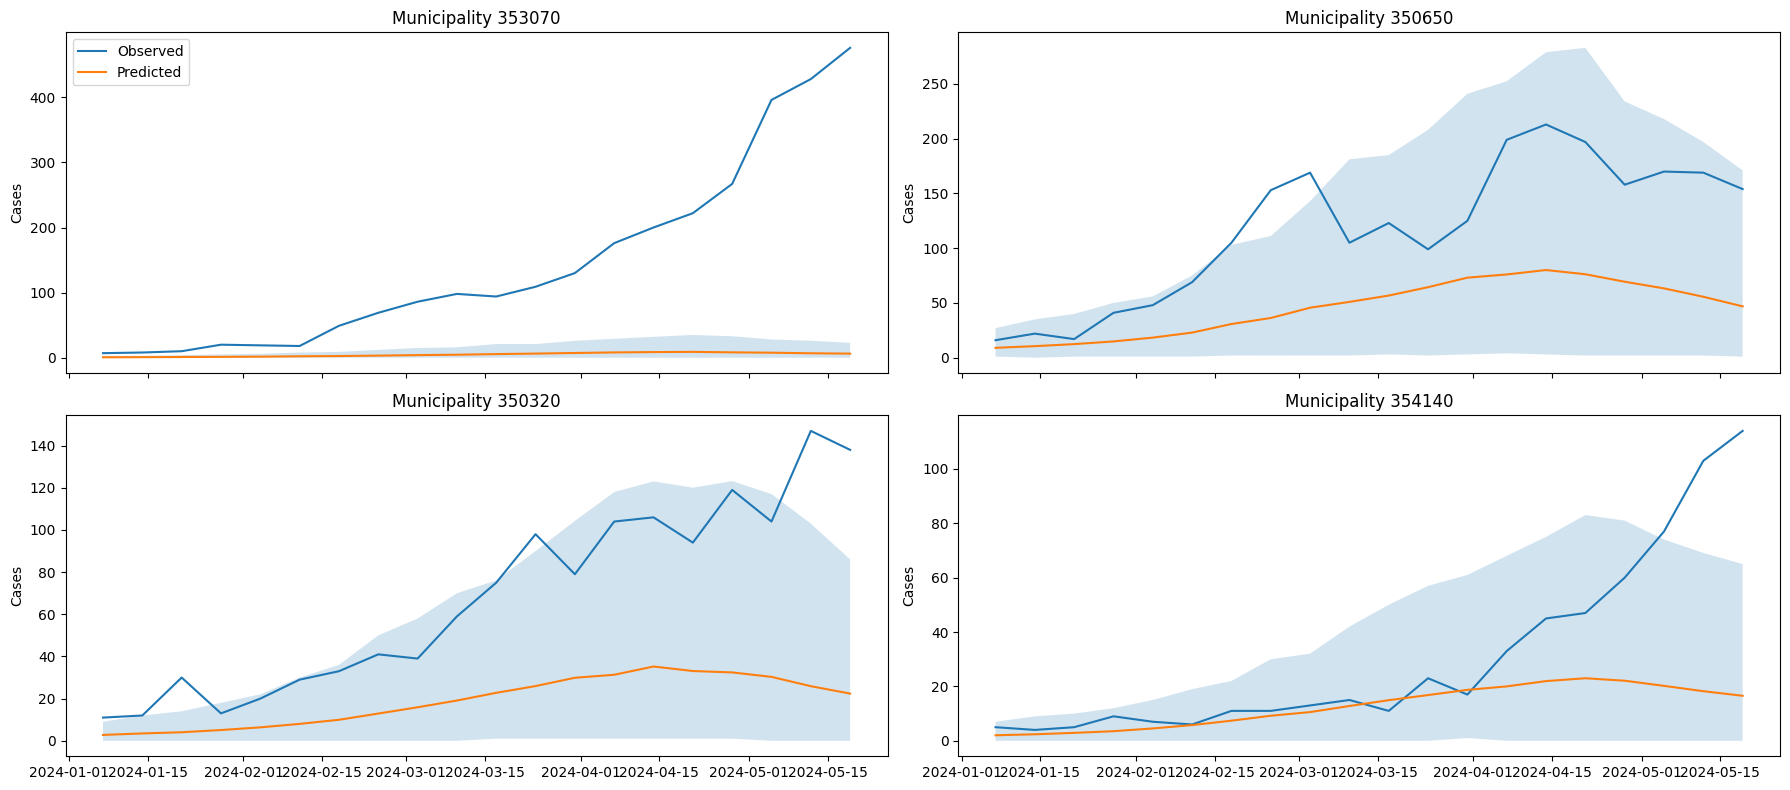

In [ ]:
# Top 6 municipalities by total observed cases in the test set
top6 = (
    pred_df.groupby("mun_code")["y_true"]
    .sum()
    .sort_values(ascending=False)
    .tail(4)
    .index
)

fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for ax, m in zip(axes, top6):

    d = pred_df.loc[pred_df["mun_code"] == m].sort_values("date")

    ax.plot(d["date"], d["y_true"], label="Observed")
    ax.plot(d["date"], d["y_pred"], label="Predicted")

    ax.fill_between(
        d["date"],
        d["y_lower"],
        d["y_upper"],
        alpha=0.2
    )

    ax.set_title(f"Municipality {m}")
    ax.set_ylabel("Cases")

axes[0].legend()

plt.tight_layout()
plt.show()

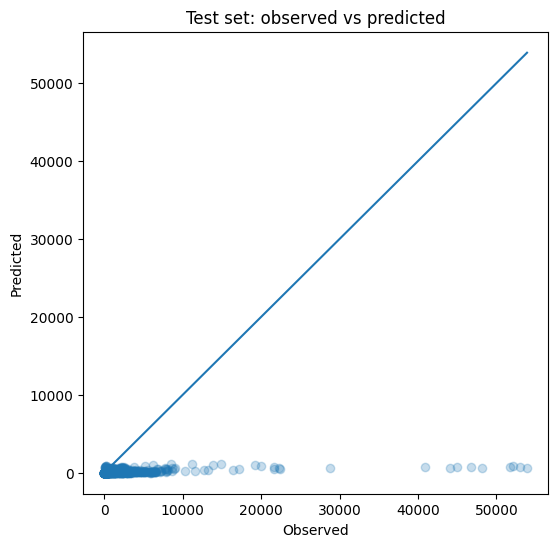

In [ ]:
# Predicted vs observed scatter
plt.figure(figsize=(6, 6))
plt.scatter(pred_df["y_true"], pred_df["y_pred"], alpha=0.25)
m = max(pred_df["y_true"].max(), pred_df["y_pred"].max())
plt.plot([0, m], [0, m])
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Test set: observed vs predicted")
plt.show()